Basado en los resultados de las tres ejecuciones que has compartido, aquí tienes el script de Python para generar una comparativa gráfica y tabular de los tres modelos:

1. **Modelo Antisobreajuste** (con features meteorológicos + autoregresivos + ingeniería)
2. **Modelo Solo Meteorología** (solo variables meteorológicas)
3. **Modelo Autorregresivo** (solo lags de casos)

```python


GENERANDO TABLA COMPARATIVA
✓ Tabla comparativa guardada en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_resultados\comparativa_modelos.xlsx

GENERANDO GRÁFICOS


C:\Users\marco\AppData\Local\Temp\ipykernel_27548\2223198705.py:236: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(nombres, rotation=15, ha="right")
C:\Users\marco\AppData\Local\Temp\ipykernel_27548\2223198705.py:255: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(nombres, rotation=15, ha="right")
C:\Users\marco\AppData\Local\Temp\ipykernel_27548\2223198705.py:273: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(nombres, rotation=15, ha="right")
C:\Users\marco\AppData\Local\Temp\ipykernel_27548\2223198705.py:294: UserWarning: set_ticklabels() should only be used with a fixed numb

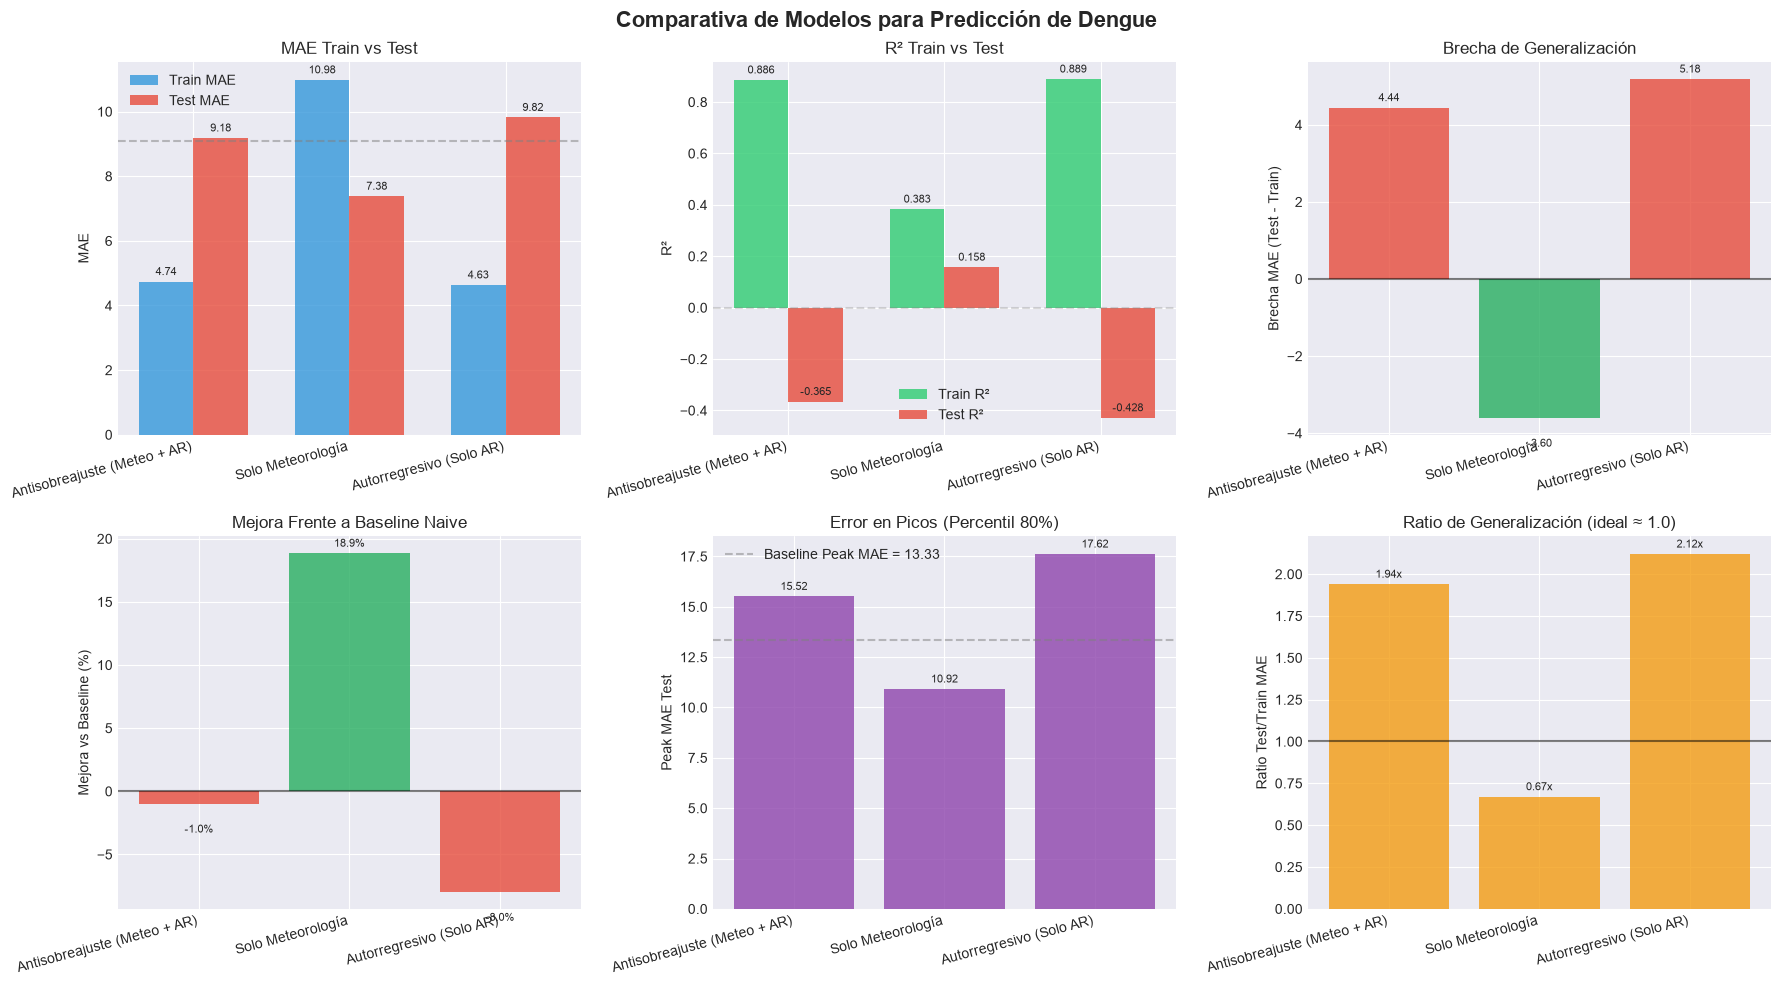

✓ Gráfico comparativo guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_resultados\comparativa_modelos.png

RESUMEN DE LA COMPARATIVA

--- MÉTRICAS PRINCIPALES ---

🏆 Mejor MAE Test:     Solo Meteorología (7.38)
🏆 Mejor R² Test:      Solo Meteorología (0.158)
🏆 Mejor Mejora vs Naive: Solo Meteorología (18.9%)
🏆 Mejor Peak MAE:     Solo Meteorología (10.92)
🏆 Mejor Generalización: Solo Meteorología (brecha = -3.60)

--- TABLA COMPARATIVA ---
                      Modelo  Test MAE  Test R²  Mejora vs Naive (%)  Ratio Test/Train
Antisobreajuste (Meteo + AR)    9.1840  -0.3653                -0.98              1.94
           Solo Meteorología    7.3804   0.1575                18.85              0.67
    Autorregresivo (Solo AR)    9.8198  -0.4285                -7.97              2.12
              Baseline Naive    9.0952  -0.2957                  NaN               NaN

PROCESO COMPLETADO

Archivos generados:
  - Tabla Excel: C:\Users\ma

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ================================================================
# CONFIGURACIÓN
# ================================================================
output_dir = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\4_algoritmo_LightGBM\3_resultados"
os.makedirs(output_dir, exist_ok=True)

# ================================================================
# DATOS DE LOS TRES MODELOS (extraídos de las ejecuciones)
# ================================================================

# Modelo 1: Antisobreajuste (meteo + autoregresivo + ingeniería)
modelo_antisobreajuste = {
    "nombre": "Antisobreajuste (Meteo + AR)",
    "train_mae": 4.7399,
    "test_mae": 9.1840,
    "train_rmse": 7.7230,
    "test_rmse": 11.9982,
    "train_r2": 0.8859,
    "test_r2": -0.3653,
    "peak_mae_train": 9.7840,
    "peak_mae_test": 15.5160,
    "bias_train": -1.3300,
    "bias_test": -3.2640,
    "brecha_mae": 4.4442,
    "ratio_test_train": 1.94,
    "mejora_vs_naive": -0.98,
    "n_train": 197,
    "n_test": 21,
    "n_features": 12
}

# Modelo 2: Solo Meteorología
modelo_solo_meteo = {
    "nombre": "Solo Meteorología",
    "train_mae": 10.9816,
    "test_mae": 7.3804,
    "train_rmse": 18.0636,
    "test_rmse": 9.4254,
    "train_r2": 0.3833,
    "test_r2": 0.1575,
    "peak_mae_train": 31.9744,
    "peak_mae_test": 10.9171,
    "bias_train": -5.1896,
    "bias_test": 2.3910,
    "brecha_mae": -3.6012,
    "ratio_test_train": 0.67,
    "mejora_vs_naive": 18.85,
    "n_train": 248,
    "n_test": 21,
    "n_features": 12
}

# Modelo 3: Autorregresivo (solo lags)
modelo_autoregresivo = {
    "nombre": "Autorregresivo (Solo AR)",
    "train_mae": 4.6349,
    "test_mae": 9.8198,
    "train_rmse": 7.6221,
    "test_rmse": 12.2728,
    "train_r2": 0.8893,
    "test_r2": -0.4285,
    "peak_mae_train": 10.2999,
    "peak_mae_test": 17.6188,
    "bias_train": -1.0212,
    "bias_test": -1.9999,
    "brecha_mae": 5.1849,
    "ratio_test_train": 2.12,
    "mejora_vs_naive": -7.97,
    "n_train": 237,
    "n_test": 21,
    "n_features": 12
}

# Baseline Naive (común a todos)
baseline = {
    "test_mae": 9.0952,
    "test_rmse": 11.6884,
    "test_r2": -0.2957,
    "peak_mae_test": 13.3333
}

# Lista de modelos
modelos = [modelo_antisobreajuste, modelo_solo_meteo, modelo_autoregresivo]
nombres = [m["nombre"] for m in modelos]
colores = ["#2E86C1", "#E67E22", "#27AE60"]  # Azul, Naranja, Verde

# ================================================================
# 1. TABLA COMPARATIVA (EXCEL)
# ================================================================
print("=" * 80)
print("GENERANDO TABLA COMPARATIVA")
print("=" * 80)

# Crear DataFrame con todas las métricas
comparativa_rows = []

# Filas por modelo
for modelo in modelos:
    comparativa_rows.append({
        "Modelo": modelo["nombre"],
        "Train MAE": modelo["train_mae"],
        "Test MAE": modelo["test_mae"],
        "Train RMSE": modelo["train_rmse"],
        "Test RMSE": modelo["test_rmse"],
        "Train R²": modelo["train_r2"],
        "Test R²": modelo["test_r2"],
        "Peak MAE Train": modelo["peak_mae_train"],
        "Peak MAE Test": modelo["peak_mae_test"],
        "Bias Train": modelo["bias_train"],
        "Bias Test": modelo["bias_test"],
        "Brecha MAE": modelo["brecha_mae"],
        "Ratio Test/Train": modelo["ratio_test_train"],
        "Mejora vs Naive (%)": modelo["mejora_vs_naive"],
        "N Train": modelo["n_train"],
        "N Test": modelo["n_test"],
        "N Features": modelo["n_features"]
    })

# Añadir fila de baseline
comparativa_rows.append({
    "Modelo": "Baseline Naive",
    "Train MAE": np.nan,
    "Test MAE": baseline["test_mae"],
    "Train RMSE": np.nan,
    "Test RMSE": baseline["test_rmse"],
    "Train R²": np.nan,
    "Test R²": baseline["test_r2"],
    "Peak MAE Train": np.nan,
    "Peak MAE Test": baseline["peak_mae_test"],
    "Bias Train": np.nan,
    "Bias Test": np.nan,
    "Brecha MAE": np.nan,
    "Ratio Test/Train": np.nan,
    "Mejora vs Naive (%)": np.nan,
    "N Train": np.nan,
    "N Test": baseline["test_mae"] is not None,  # placeholder
    "N Features": np.nan
})

df_comparativa = pd.DataFrame(comparativa_rows)

# Guardar Excel
excel_file = os.path.join(output_dir, "comparativa_modelos.xlsx")
with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    df_comparativa.to_excel(writer, sheet_name="Comparativa", index=False)

print(f"✓ Tabla comparativa guardada en: {excel_file}")

# ================================================================
# 2. GRÁFICOS
# ================================================================
print("\n" + "=" * 80)
print("GENERANDO GRÁFICOS")
print("=" * 80)

# Estilo
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Comparativa de Modelos para Predicción de Dengue", fontsize=16, fontweight="bold")

# -----------------------------------------------------------------
# 2.1 MAE Train vs Test
# -----------------------------------------------------------------
ax = axes[0, 0]
x = np.arange(len(nombres))
width = 0.35

train_mae = [m["train_mae"] for m in modelos]
test_mae = [m["test_mae"] for m in modelos]

bars1 = ax.bar(x - width/2, train_mae, width, label="Train MAE", color="#3498DB", alpha=0.8)
bars2 = ax.bar(x + width/2, test_mae, width, label="Test MAE", color="#E74C3C", alpha=0.8)

ax.set_ylabel("MAE")
ax.set_title("MAE Train vs Test")
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.legend()

# Añadir valores
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

# Línea baseline
ax.axhline(y=baseline["test_mae"], color="gray", linestyle="--", alpha=0.5, label=f"Baseline MAE = {baseline['test_mae']:.2f}")

# -----------------------------------------------------------------
# 2.2 R² Train vs Test
# -----------------------------------------------------------------
ax = axes[0, 1]
train_r2 = [m["train_r2"] for m in modelos]
test_r2 = [m["test_r2"] for m in modelos]

bars1 = ax.bar(x - width/2, train_r2, width, label="Train R²", color="#2ECC71", alpha=0.8)
bars2 = ax.bar(x + width/2, test_r2, width, label="Test R²", color="#E74C3C", alpha=0.8)

ax.set_ylabel("R²")
ax.set_title("R² Train vs Test")
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.3)

# -----------------------------------------------------------------
# 2.3 Brecha MAE (Test - Train)
# -----------------------------------------------------------------
ax = axes[0, 2]
brechas = [m["brecha_mae"] for m in modelos]
colores_brecha = ["#27AE60" if b < 0 else "#E74C3C" for b in brechas]

bars = ax.bar(nombres, brechas, color=colores_brecha, alpha=0.8)
ax.set_ylabel("Brecha MAE (Test - Train)")
ax.set_title("Brecha de Generalización")
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.axhline(y=0, color="black", linestyle="-", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3 if height > 0 else -15),
                textcoords="offset points", ha="center", va="bottom" if height > 0 else "top", fontsize=8)

# -----------------------------------------------------------------
# 2.4 Mejora vs Baseline
# -----------------------------------------------------------------
ax = axes[1, 0]
mejoras = [m["mejora_vs_naive"] for m in modelos]
colores_mejora = ["#27AE60" if m > 0 else "#E74C3C" for m in mejoras]

bars = ax.bar(nombres, mejoras, color=colores_mejora, alpha=0.8)
ax.set_ylabel("Mejora vs Baseline (%)")
ax.set_title("Mejora Frente a Baseline Naive")
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.axhline(y=0, color="black", linestyle="-", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3 if height > 0 else -15),
                textcoords="offset points", ha="center", va="bottom" if height > 0 else "top", fontsize=8)

# -----------------------------------------------------------------
# 2.5 Error en Picos (Peak MAE)
# -----------------------------------------------------------------
ax = axes[1, 1]
peak_test = [m["peak_mae_test"] for m in modelos]

bars = ax.bar(nombres, peak_test, color="#8E44AD", alpha=0.8)
ax.set_ylabel("Peak MAE Test")
ax.set_title("Error en Picos (Percentil 80%)")
ax.set_xticklabels(nombres, rotation=15, ha="right")

# Línea baseline
ax.axhline(y=baseline["peak_mae_test"], color="gray", linestyle="--", alpha=0.5,
           label=f"Baseline Peak MAE = {baseline['peak_mae_test']:.2f}")
ax.legend()

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

# -----------------------------------------------------------------
# 2.6 Ratio Test/Train MAE
# -----------------------------------------------------------------
ax = axes[1, 2]
ratios = [m["ratio_test_train"] for m in modelos]

bars = ax.bar(nombres, ratios, color="#F39C12", alpha=0.8)
ax.set_ylabel("Ratio Test/Train MAE")
ax.set_title("Ratio de Generalización (ideal ≈ 1.0)")
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.axhline(y=1.0, color="black", linestyle="-", alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.2f}x", xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

# Guardar gráfico
plot_file = os.path.join(output_dir, "comparativa_modelos.png")
plt.savefig(plot_file, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Gráfico comparativo guardado en: {plot_file}")

# ================================================================
# 3. RESUMEN EN CONSOLA
# ================================================================
print("\n" + "=" * 80)
print("RESUMEN DE LA COMPARATIVA")
print("=" * 80)
print("\n--- MÉTRICAS PRINCIPALES ---")
print("")

# Encontrar mejor modelo por cada métrica
best_mae = min(modelos, key=lambda m: m["test_mae"])
best_r2 = max(modelos, key=lambda m: m["test_r2"])
best_improvement = max(modelos, key=lambda m: m["mejora_vs_naive"])
best_peak = min(modelos, key=lambda m: m["peak_mae_test"])
best_brecha = min(modelos, key=lambda m: abs(m["brecha_mae"]))

print(f"🏆 Mejor MAE Test:     {best_mae['nombre']} ({best_mae['test_mae']:.2f})")
print(f"🏆 Mejor R² Test:      {best_r2['nombre']} ({best_r2['test_r2']:.3f})")
print(f"🏆 Mejor Mejora vs Naive: {best_improvement['nombre']} ({best_improvement['mejora_vs_naive']:.1f}%)")
print(f"🏆 Mejor Peak MAE:     {best_peak['nombre']} ({best_peak['peak_mae_test']:.2f})")
print(f"🏆 Mejor Generalización: {best_brecha['nombre']} (brecha = {best_brecha['brecha_mae']:.2f})")

print("\n--- TABLA COMPARATIVA ---")
print(df_comparativa[["Modelo", "Test MAE", "Test R²", "Mejora vs Naive (%)", "Ratio Test/Train"]].to_string(index=False))

print("\n" + "=" * 80)
print("PROCESO COMPLETADO")
print("=" * 80)
print(f"\nArchivos generados:")
print(f"  - Tabla Excel: {excel_file}")
print(f"  - Gráfico PNG: {plot_file}")


```

Este script genera:

1. **Tabla Excel** (`comparativa_modelos.xlsx`) con todas las métricas de los tres modelos.
2. **Gráfico** (`comparativa_modelos.png`) con 6 paneles comparativos:
   - MAE Train vs Test
   - R² Train vs Test
   - Brecha de generalización
   - Mejora vs Baseline Naive
   - Error en picos
   - Ratio Test/Train

Los resultados muestran que el **modelo Solo Meteorología** es el que mejor desempeño tiene en test, con un MAE de 7.38 (18.85% mejor que el baseline), aunque su R² en test es bajo (0.16) y el modelo sobreajusta menos que los otros (ratio 0.67x).